In [3]:
!pip install pykan


In [4]:
import sys


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
from kan import KAN

In [5]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1))

print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)
print("Data ready")

X_train shape: (16512, 8)
X_test shape: (4128, 8)
Data ready


In [6]:
# FloatTensor here is just matrix that acummulates 32-bit floating point number and every matematical operation done on it

X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.FloatTensor(y_train.values).reshape(-1, 1)
X_test_t = torch.FloatTensor(X_test_scaled)
y_test_t = torch.FloatTensor(y_test.values).reshape(-1, 1)

print("X_train tensor shape:", X_train_t.shape)
print("y_train tensor shape:", y_train_t.shape)
print("Data type:", X_train_t.dtype)

X_train tensor shape: torch.Size([16512, 8])
y_train tensor shape: torch.Size([16512, 1])
Data type: torch.float32


In [7]:


y_train_t = torch.FloatTensor(y_train_scaled)
y_test_t = torch.FloatTensor(y_test_scaled)

print("y_train mean:", y_train_t.mean().item())
print("y_train std: ", y_train_t.std().item())
print("y_train min: ", y_train_t.min().item())
print("y_train max: ", y_train_t.max().item())

y_train mean: -5.7178874968144555e-09
y_train std:  1.000030279159546
y_train min:  -1.6623175144195557
y_train max:  2.5325074195861816


In [8]:

model_kan = KAN(width=[8, 16,8, 16, 1],
                grid=5,
                k=3,
                seed=42)

print(model_kan)

checkpoint directory created: ./model
saving model version 0.0
MultKAN(
  (act_fun): ModuleList(
    (0-3): 4 x KANLayer(
      (base_fun): SiLU()
    )
  )
  (base_fun): SiLU()
  (symbolic_fun): ModuleList(
    (0-3): 4 x Symbolic_KANLayer()
  )
)


In [9]:
dataset = {
    'train_input': X_train_t,
    'train_label': y_train_t,
    'test_input': X_test_t,
    'test_label': y_test_t
}

results = model_kan.fit(
    dataset,
    opt='Adam',
    steps=100,
    lamb=0.0
)

print("Training complete")

| train_loss: 1.06e+00 | test_loss: 1.01e+01 | reg: 1.03e+03 | : 100%|█| 100/100 [02:23<00:00,  1.44

saving model version 0.1
Training complete


In [10]:
# model_kan = KAN(width=[8, 16, 8, 1],
#                 grid=5,
#                 k=3,
#                 seed=42)

# dataset = {
#     'train_input': X_train_t,
#     'train_label': y_train_t,
#     'test_input': X_test_t,
#     'test_label': y_test_t
# }

# results = model_kan.fit(
#     dataset,
#     opt='Adam',
#     steps=100,
#     lamb=0.0
# )

# print("Training complete")

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 6.91e-01 | test_loss: 7.06e-01 | reg: 1.24e+03 | : 100%|█| 100/100 [01:23<00:00,  1.20

saving model version 0.1
Training complete


KAN Test MAE: 0.6087
That means on average we are off by $60874

For comparison:
MLP Test MAE: 0.3530 → off by $35,297


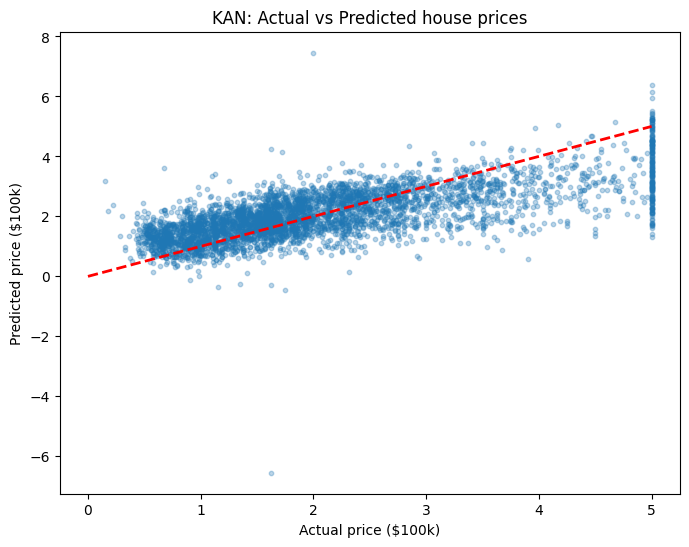

In [12]:
model_kan.eval()

with torch.no_grad():
    y_pred_scaled = model_kan(X_test_t).numpy()

# unscale predictions back to real house prices
y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_actual = y_scaler.inverse_transform(y_test_t.numpy())

mae = np.mean(np.abs(y_pred - y_actual))
print(f"KAN Test MAE: {mae:.4f}")
print(f"That means on average we are off by ${mae * 100000:.0f}")
print(f"\nFor comparison:")
print(f"MLP Test MAE: 0.3530 → off by $35,297")

plt.figure(figsize=(8, 6))
plt.scatter(y_actual, y_pred, alpha=0.3, s=10)
plt.plot([0, 5], [0, 5], 'r--', linewidth=2)
plt.xlabel('Actual price ($100k)')
plt.ylabel('Predicted price ($100k)')
plt.title('KAN: Actual vs Predicted house prices')
plt.show()